# Assignment 04 — Field Mapping

**Objective:** Build a layered geospatial map of Ohio Maumee watershed fields with soil properties.

**Data sources:**
- `data/fields/ohio_maumee_20.geojson` — 20 field boundaries (EPSG:4326)
- `data/soil/ohio_maumee_20_soil.csv` — SSURGO soil data (joins via `field_id`)

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load data

In [3]:
# Load field boundaries
fields = gpd.read_file('../data/fields/ohio_maumee_20.geojson')
print(f'Fields CRS: {fields.crs}')
print(f'Fields shape: {fields.shape}')
fields.head()

Fields CRS: EPSG:4326
Fields shape: (20, 4)


,field_id,crop:name,area_acres,geometry
0,391623002240612,Corn,16.609715,"POLYGON ((-83.38221 41.66747, -83.38221 41.667..."
1,391623003947118,Winter Wheat,11.123554,"POLYGON ((-83.24521 41.33171, -83.24521 41.331..."
2,391623004118842,Soybeans,15.768339,"POLYGON ((-84.00434 41.63727, -84.00398 41.637..."
3,391623002242386,Soybeans,5.809587,"POLYGON ((-83.20075 41.56892, -83.20075 41.567..."
4,391623004305517,Soybeans,21.815450,"POLYGON ((-82.77572 41.40485, -82.77536 41.404..."


In [4]:
# Load soil data
soil = pd.read_csv('../data/soil/ohio_maumee_20_soil.csv')
print(f'Soil shape: {soil.shape}')
soil.head()

Soil shape: (124, 16)


,mukey,muname,compname,comppct_r,drainagecl,hzdept_r,hzdepb_r,om_r,ph1to1h2o_r,awc_r,claytotal_r,sandtotal_r,silttotal_r,dbthirdbar_r,cec7_r,field_id
0,169841,"Fulton silty clay loam, 0 to 2 percent slopes",Fulton,90,Somewhat poorly drained,0,23,2.50,6.5,0.18,33.5,17.5,49.0,1.45,28.0,391623002240612
1,169841,"Fulton silty clay loam, 0 to 2 percent slopes",Fulton,90,Somewhat poorly drained,23,81,0.75,6.7,0.14,52.5,3.1,44.4,1.55,29.0,391623002240612
2,169850,"Latty silty clay, till substratum, 0 to 1 perc...",Latty,87,Very poorly drained,0,18,4.80,6.5,0.13,44.0,15.0,41.0,1.29,24.0,391623002240612
3,169850,"Latty silty clay, till substratum, 0 to 1 perc...",Latty,87,Very poorly drained,18,60,2.00,7.2,0.12,49.0,10.0,41.0,1.33,20.9,391623002240612
4,2399584,"Hoytville silty clay loam, 0 to 1 percent slopes",Hoytville,90,Very poorly drained,0,23,4.50,6.7,0.21,39.0,19.0,42.0,1.32,26.5,391623003947118


## Verify CRS alignment

The soil CSV is tabular (no geometry) and joins to fields via `field_id`. No `.to_crs()` needed.

In [5]:
print(f'Fields CRS: {fields.crs}')
print(f'Soil has no geometry — joins via field_id')
print(f'Common key: field_id')
print(f'  Fields field_id count: {fields["field_id"].nunique()}')
print(f'  Soil field_id count: {soil["field_id"].nunique()}')

Fields CRS: EPSG:4326
Soil has no geometry — joins via field_id
Common key: field_id
  Fields field_id count: 20
  Soil field_id count: 20


## Plot field boundaries (base layer)

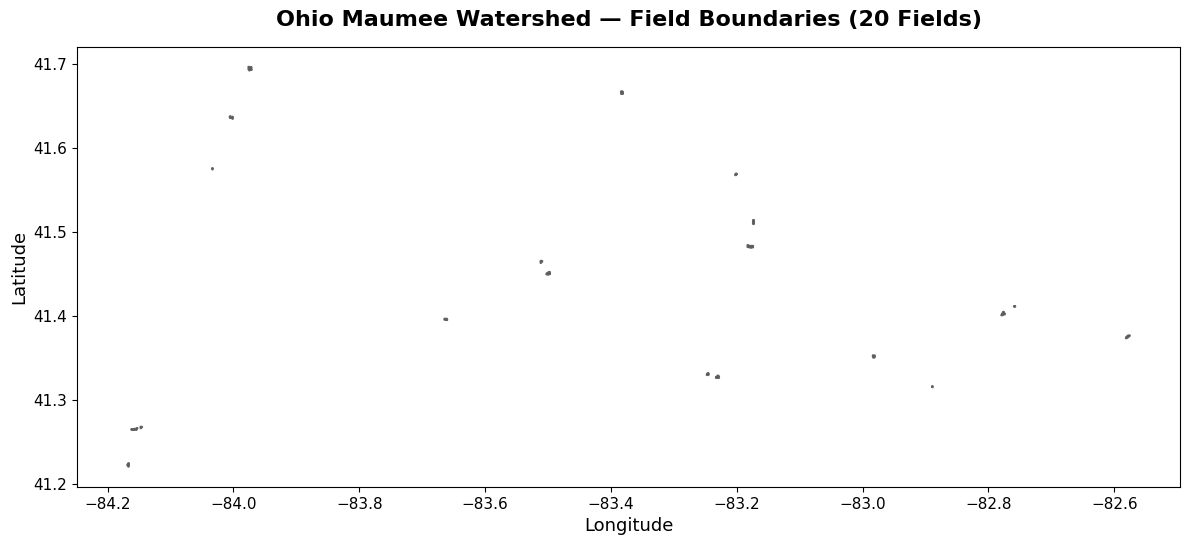

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
fields.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=1.5, alpha=0.6)

ax.set_title('Ohio Maumee Watershed — Field Boundaries (20 Fields)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## Overlay a Second Spatial Dataset

Dominant soils found for 20 fields
       field_id dominant_soil  comppct_r
391623002243787     St. Clair         97
391623001193287        Spinks         95
391623002233624      Nappanee         95
391623001532073       Mermill         93
391623004118842       Colonie         92
391623004305517           Fox         90
391623004305230        Kibbie         90
391623004291427     Hoytville         90
391623003947118     Hoytville         90
391623002240612        Fulton         90
391623004307136        Kibbie         90
391623000245868     Hoytville         90
391623004119707     Hoytville         90
391623004117828     Hoytville         90
391623002242386        Toledo         90
391623004307950     Hoytville         90
391623003947189     Dunbridge         90
391623004303760        Toledo         90
391623000245685     Hoytville         90
391623001532050     Hoytville         90


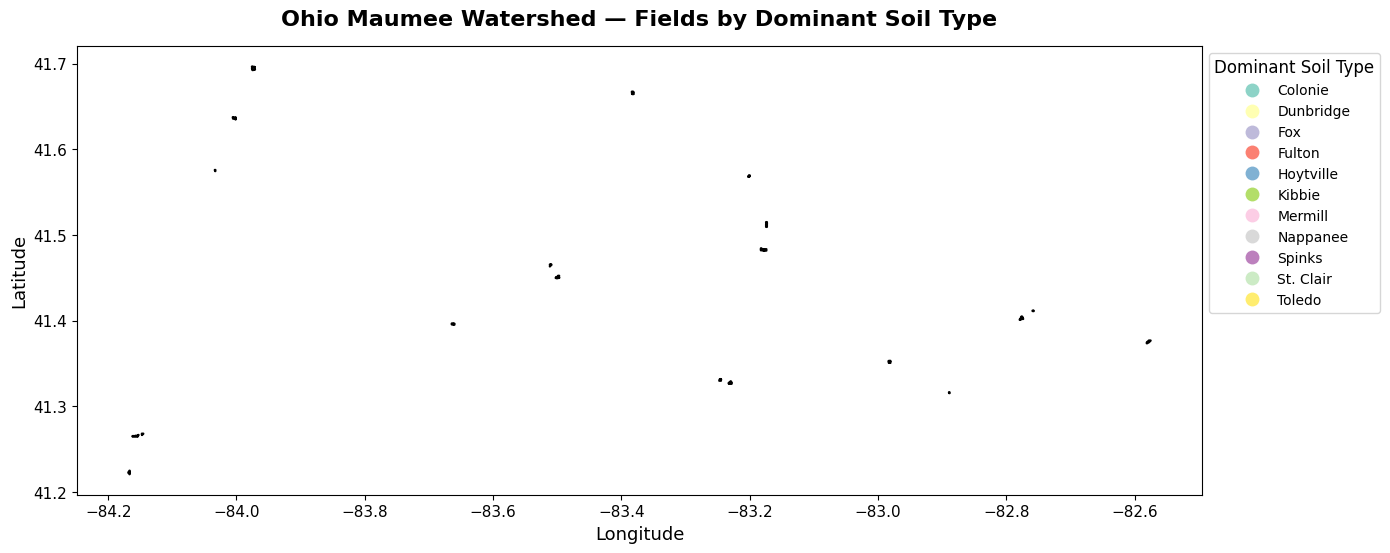

In [8]:
# --- Merge: Get dominant soil type per field ---
# Each field may have multiple soil components; pick the one with highest percentage
dominant_soil = (soil
    .sort_values('comppct_r', ascending=False)
    .drop_duplicates(subset='field_id', keep='first')
    [['field_id', 'compname', 'comppct_r', 'drainagecl']]
    .rename(columns={'compname': 'dominant_soil'}))
print(f'Dominant soils found for {len(dominant_soil)} fields')
print(dominant_soil[['field_id', 'dominant_soil', 'comppct_r']].to_string(index=False))

# Merge with field geometries (align field_id types)
dominant_soil['field_id'] = dominant_soil['field_id'].astype(str)
fields_soil = fields.merge(dominant_soil, on='field_id', how='left')

# --- Plot: Fields colored by dominant soil type ---
fig, ax = plt.subplots(figsize=(14, 10))
fields_soil.plot(column='dominant_soil',
                 ax=ax,
                 edgecolor='black',
                 linewidth=1.5,
                 legend=True,
                 cmap='Set3',
                 legend_kwds={'title': 'Dominant Soil Type',
                              'fontsize': 10,
                              'title_fontsize': 12,
                              'loc': 'upper left',
                              'bbox_to_anchor': (1, 1)})
ax.set_title('Ohio Maumee Watershed — Fields by Dominant Soil Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## Add a legend, a north arrow, and clear labels

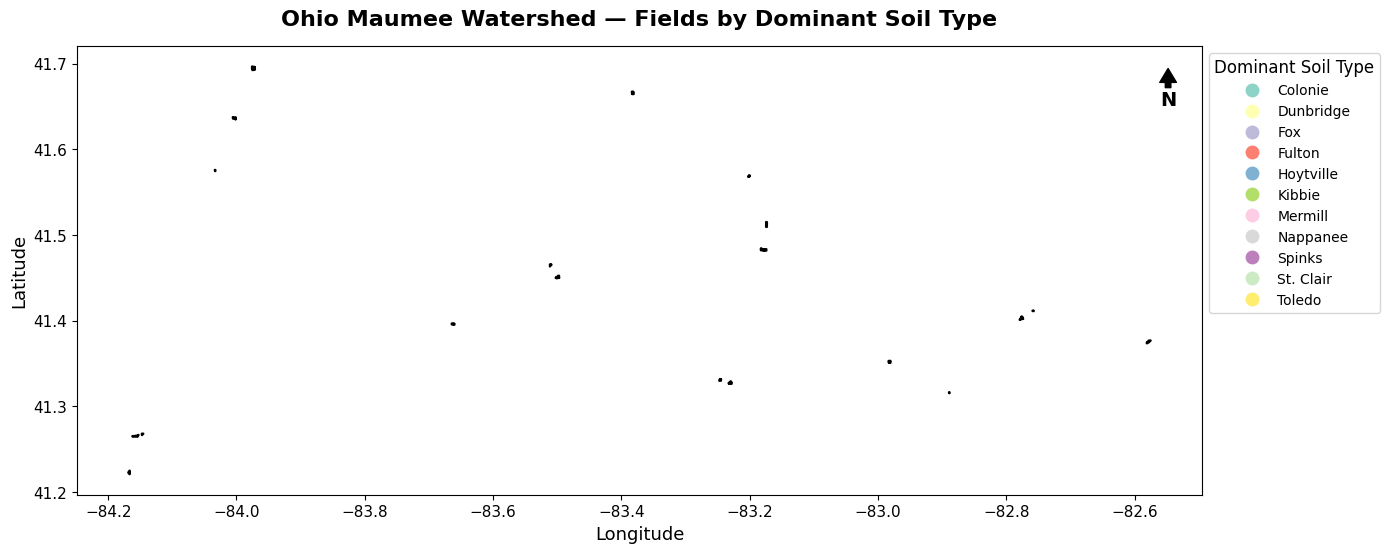

In [11]:
import matplotlib.patches as mpatches
# --- Plot: Fields colored by dominant soil type (clean version) ---
fig, ax = plt.subplots(figsize=(14, 10))
fields_soil.plot(column='dominant_soil',
                 ax=ax,
                 edgecolor='black',
                 linewidth=1.5,
                 legend=True,
                 cmap='Set3',
                 legend_kwds={'title': 'Dominant Soil Type',
                              'fontsize': 10,
                              'title_fontsize': 12,
                              'loc': 'upper left',
                              'bbox_to_anchor': (1, 1)})
# --- North arrow ---
x, y, arrow_length = 0.97, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=4, headwidth=12, headlength=10),
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            xycoords=ax.transAxes)
# --- Title and axis labels ---
ax.set_title('Ohio Maumee Watershed — Fields by Dominant Soil Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_51116/2403398896.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fields_buffered['geometry'] = fields_buffered.geometry.buffer(0.015)


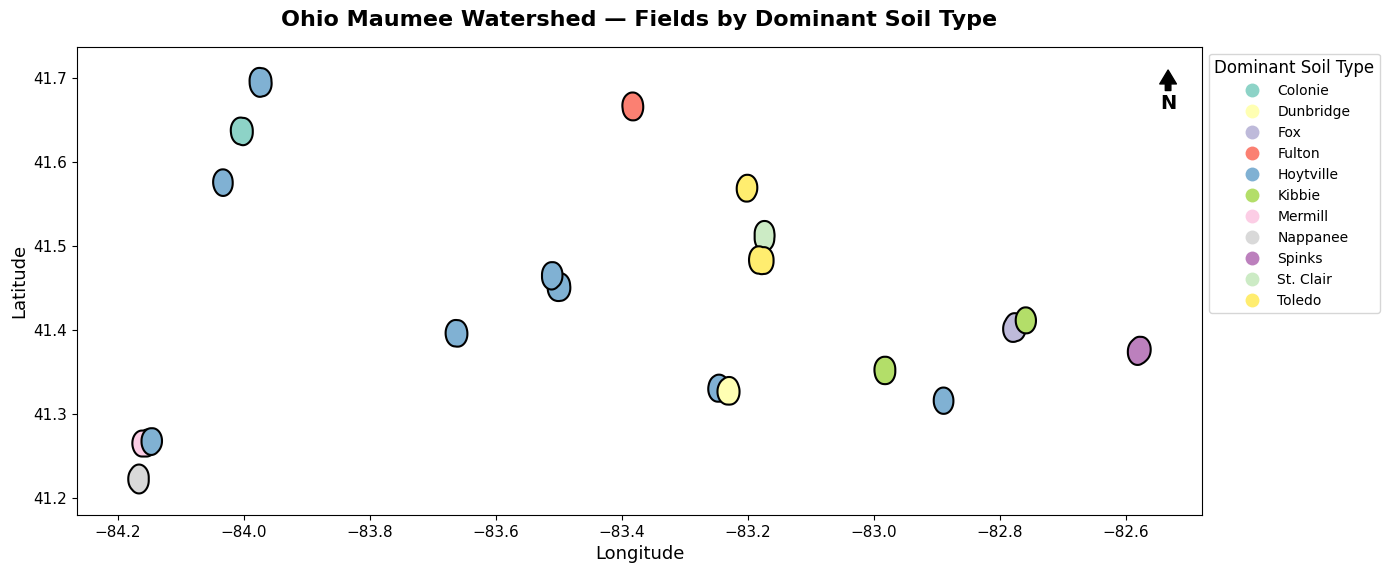

In [ ]:
# Buffered view (enlarge fields visually with a buffer):
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(14, 10))
# Buffer the geometries slightly so they're visible at full extent
fields_buffered = fields_soil.copy()
fields_buffered['geometry'] = fields_buffered.geometry.buffer(0.015)
fields_buffered.plot(column='dominant_soil',
                     ax=ax,
                     edgecolor='black',
                     linewidth=1.5,
                     legend=True,
                     cmap='Set3',
                     legend_kwds={'title': 'Dominant Soil Type',
                                  'fontsize': 10,
                                  'title_fontsize': 12,
                                  'loc': 'upper left',
                                  'bbox_to_anchor': (1, 1)})
# North arrow
x, y, arrow_length = 0.97, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=4, headwidth=12, headlength=10),
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            xycoords=ax.transAxes)
ax.set_title('Ohio Maumee Watershed — Fields by Dominant Soil Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## Interpretation

The map shows 20 agricultural fields in the Maumee River watershed, colored by their dominant soil type based on USDA Natural Resources Conservation Service Soil Survey Geographic Database (SSURGO) data. Hoytville soil appears most frequently across fields from the western to central parts of the watershed, while other soils such as Toledo, Nappanee, and Colonie occur less often. In total, 11 different soil types are observed across the study area, indicating substantial soil diversity that can influence drainage management, nutrient retention, and crop suitability.

## Final Map for the Dashboard

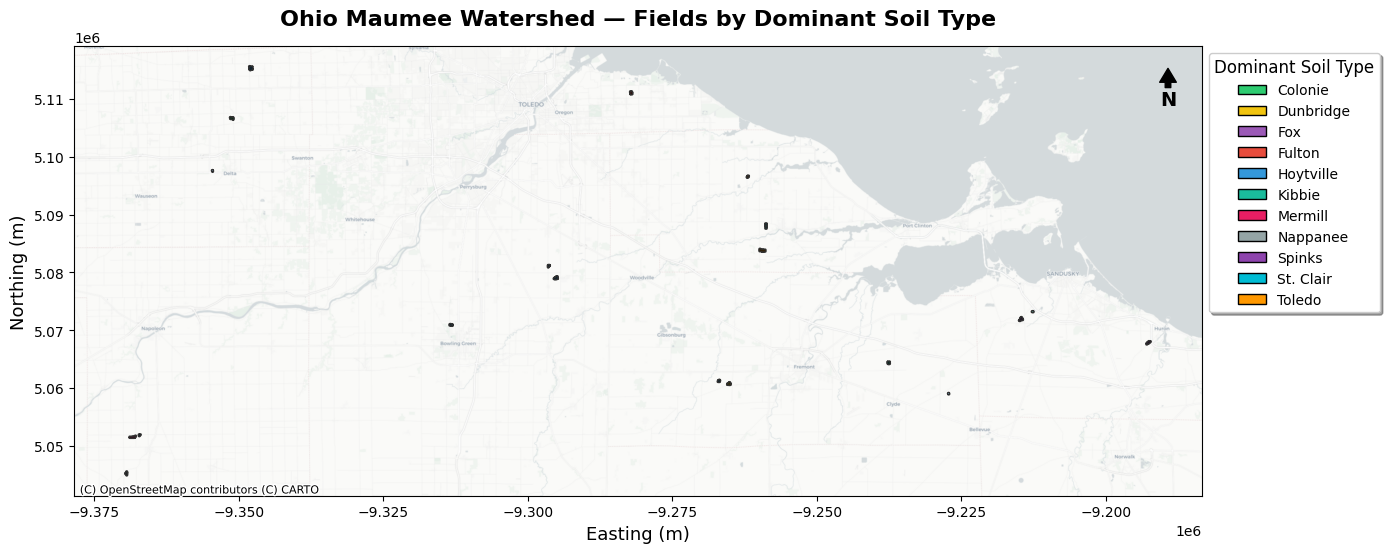

Saved: output/dashboard_assets/fields_soil_map_real_boundaries.png


In [16]:
import contextily as ctx
import matplotlib.patches as mpatches
# --- Reproject to Web Mercator (EPSG:3857) for basemap tiles ---
fields_soil_3857 = fields_soil.to_crs(epsg=3857)
# --- Color palette ---
soil_colors = {
    'Colonie': '#2ecc71', 'Dunbridge': '#f1c40f', 'Fox': '#9b59b6',
    'Fulton': '#e74c3c', 'Hoytville': '#3498db', 'Kibbie': '#1abc9c',
    'Mermill': '#e91e63', 'Nappanee': '#95a5a6', 'Spinks': '#8e44ad',
    'St. Clair': '#00bcd4', 'Toledo': '#ff9800'
}
# Assign color per row
fields_soil_3857['color'] = fields_soil_3857['dominant_soil'].map(soil_colors)
# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))
fields_soil_3857.plot(ax=ax,
                      color=fields_soil_3857['color'],
                      edgecolor='black',
                      linewidth=2,
                      alpha=0.8,
                      zorder=2)
# Add basemap tiles
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
# --- Legend ---
legend_patches = [mpatches.Patch(facecolor=c, edgecolor='black', label=s)
                  for s, c in sorted(soil_colors.items())]
ax.legend(handles=legend_patches, title='Dominant Soil Type',
          fontsize=10, title_fontsize=12, loc='upper left',
          bbox_to_anchor=(1, 1), frameon=True, fancybox=True, shadow=True)
# --- North arrow ---
x, y, arrow_length = 0.97, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=4, headwidth=12, headlength=10),
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            xycoords=ax.transAxes)
# --- Labels ---
ax.set_title('Ohio Maumee Watershed — Fields by Dominant Soil Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Easting (m)', fontsize=13)
ax.set_ylabel('Northing (m)', fontsize=13)
ax.tick_params(labelsize=10)
plt.tight_layout()
fig.savefig('output/dashboard_assets/fields_soil_map_real_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: output/dashboard_assets/fields_soil_map_real_boundaries.png")

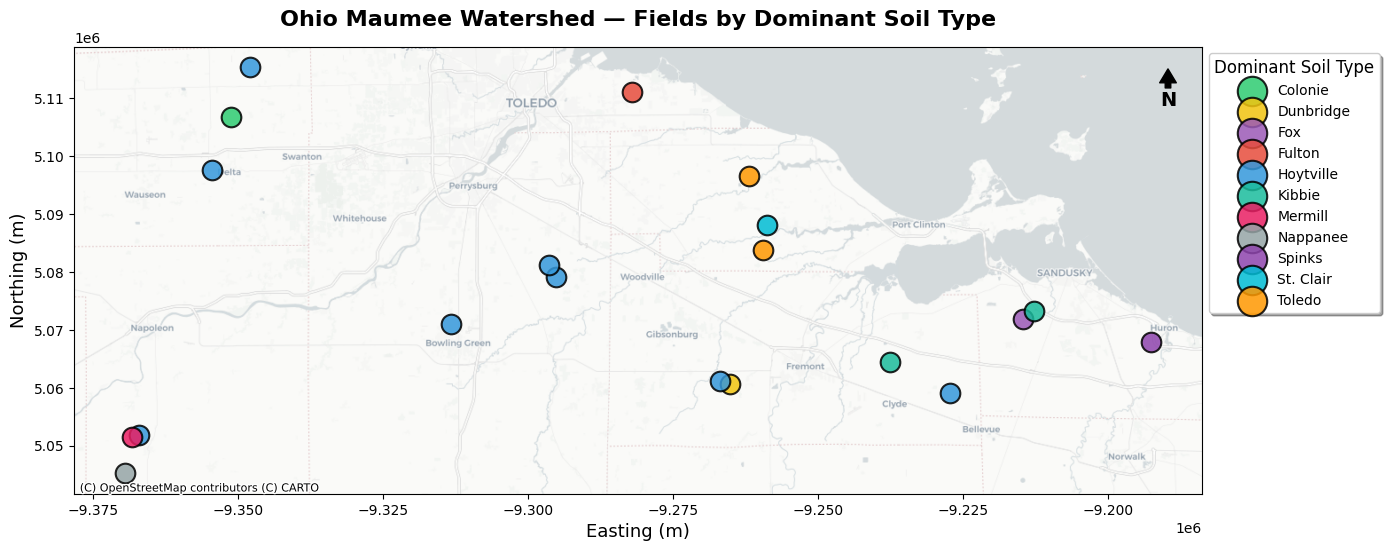

Saved: output/dashboard_assets/fields_soil_map.png


In [15]:
import contextily as ctx
import matplotlib.patches as mpatches
# --- Reproject to Web Mercator (EPSG:3857) for basemap tiles ---
fields_soil_3857 = fields_soil.to_crs(epsg=3857)
# --- Color palette ---
soil_colors = {
    'Colonie': '#2ecc71', 'Dunbridge': '#f1c40f', 'Fox': '#9b59b6',
    'Fulton': '#e74c3c', 'Hoytville': '#3498db', 'Kibbie': '#1abc9c',
    'Mermill': '#e91e63', 'Nappanee': '#95a5a6', 'Spinks': '#8e44ad',
    'St. Clair': '#00bcd4', 'Toledo': '#ff9800'
}
# Get centroids and assign colors
centroids = fields_soil_3857.copy()
centroids['geometry'] = centroids.geometry.centroid
centroids['color'] = centroids['dominant_soil'].map(soil_colors)
# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))
# Plot colored centroid markers
for soil_type, group in centroids.groupby('dominant_soil'):
    group.plot(ax=ax, color=soil_colors[soil_type],
               edgecolor='black', linewidth=1.5,
               markersize=200, alpha=0.85, zorder=3,
               label=soil_type)
# Add basemap tiles
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
# --- Legend ---
ax.legend(title='Dominant Soil Type',
          fontsize=10, title_fontsize=12, loc='upper left',
          bbox_to_anchor=(1, 1), frameon=True, fancybox=True,
          shadow=True, markerscale=1.5)
# --- North arrow ---
x, y, arrow_length = 0.97, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=4, headwidth=12, headlength=10),
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            xycoords=ax.transAxes)
# --- Labels ---
ax.set_title('Ohio Maumee Watershed — Fields by Dominant Soil Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Easting (m)', fontsize=13)
ax.set_ylabel('Northing (m)', fontsize=13)
ax.tick_params(labelsize=10)
plt.tight_layout()
fig.savefig('output/dashboard_assets/fields_soil_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: output/dashboard_assets/fields_soil_map.png")